Zadanie 7

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from keras.datasets import mnist
import numpy as np

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = train_images.reshape(-1, 1, 28, 28).astype(np.float32) / 255.0
test_images = test_images.reshape(-1, 1, 28, 28).astype(np.float32) / 255.0

train_dataset = TensorDataset(torch.tensor(train_images), torch.tensor(train_labels))
test_dataset = TensorDataset(torch.tensor(test_images), torch.tensor(test_labels))
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN() 
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)    

num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step() 
    model.eval()        
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item() 
    accuracy = correct / total
    print(f'Epoch {epoch+1}/{num_epochs}, Test Accuracy: {accuracy:.4f}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/5, Test Accuracy: 0.9821
Epoch 2/5, Test Accuracy: 0.9879
Epoch 3/5, Test Accuracy: 0.9902
Epoch 4/5, Test Accuracy: 0.9912
Epoch 5/5, Test Accuracy: 0.9899


Zadanie 9

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.7498 - loss: 0.6963 - val_accuracy: 0.8555 - val_loss: 0.3809 - learning_rate: 0.0010
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.8369 - loss: 0.4448 - val_accuracy: 0.8771 - val_loss: 0.3229 - learning_rate: 0.0010
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.8621 - loss: 0.3799 - val_accuracy: 0.8898 - val_loss: 0.2953 - learning_rate: 0.0010
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.8735 - loss: 0.3461 - val_accuracy: 0.8998 - val_loss: 0.2745 - learning_rate: 0.0010
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.8819 - loss: 0.3241 - val_accuracy: 0.9021 - val_loss: 0.2618 - learning_rate: 0.0010
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.8888 - loss: 0.3078 - val_accuracy: 0.9059 - val_loss: 0.2540 - learning_rate: 0.0010
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.8934 - l

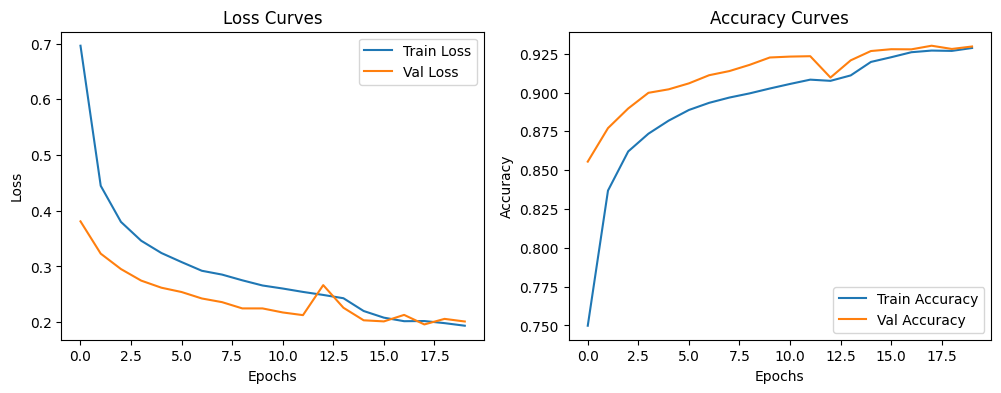

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


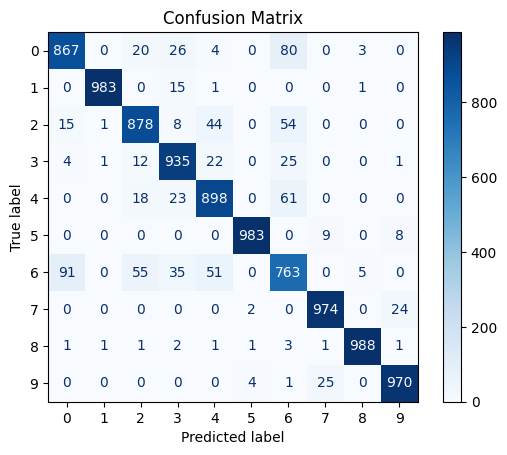

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
train_images = train_images.reshape(-1, 28, 28, 1).astype(np.float32) / 255.0
test_images = test_images.reshape(-1, 28, 28, 1).astype(np.float32) / 255.0

model = Sequential([    
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)

history = model.fit(train_images, train_labels, epochs=20, batch_size=64,   validation_split=0.2, callbacks=[early_stopping, reduce_lr])

    
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss') 
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

y_pred = model.predict(test_images)
y_pred_classes = np.argmax(y_pred, axis=1)
cm = confusion_matrix(test_labels, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


Zadanie 12

In [4]:
from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()
train_images = train_images.astype(np.float32) / 255.0
test_images = test_images.astype(np.float32) / 255.0
train_labels = train_labels.flatten()
test_labels = test_labels.flatten()

mlp_model = Sequential([
    Flatten(input_shape=(32, 32, 3)),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

mlp_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
mlp_history = mlp_model.fit(train_images, train_labels, epochs=20, batch_size=64, validation_split=0.2, callbacks=[early_stopping, reduce_lr])

cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])
cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_history = cnn_model.fit(train_images, train_labels, epochs=20, batch_size=64, validation_split=0.2, callbacks=[early_stopping, reduce_lr])
mlp_test_loss, mlp_test_acc = mlp_model.evaluate(test_images, test_labels, verbose=0)
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(test_images, test_labels, verbose=0)
print(f'MLP Test Accuracy: {mlp_test_acc:.4f}')
print(f'CNN Test Accuracy: {cnn_test_acc:.4f}')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 58s 0us/step


c:\Users\joann\Documents\DataScience\LearnIT\CODE\pythonProject\venv2\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")
c:\Users\joann\Documents\DataScience\LearnIT\CODE\pythonProject\venv2\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.1769 - loss: 2.1755 - val_accuracy: 0.2584 - val_loss: 2.0139 - learning_rate: 0.0010
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.1973 - loss: 2.1001 - val_accuracy: 0.2507 - val_loss: 2.0444 - learning_rate: 0.0010
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.2103 - loss: 2.0664 - val_accuracy: 0.2780 - val_loss: 2.0041 - learning_rate: 0.0010
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.2183 - loss: 2.0455 - val_accuracy: 0.2712 - val_loss: 2.0213 - learning_rate: 0.0010
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.2207 - loss: 2.0360 - val_accuracy: 0.2586 - val_loss: 2.0252 - learning_rate: 0.0010
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.2307 - loss: 2.0131 - val_accuracy: 0.2784 - val_loss: 1.9896 - learning_rate: 5.0000e-04
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.2365 - loss: 2.005

c:\Users\joann\Documents\DataScience\LearnIT\CODE\pythonProject\venv2\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 45ms/step - accuracy: 0.3826 - loss: 1.7127 - val_accuracy: 0.4230 - val_loss: 1.7141 - learning_rate: 0.0010
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.5373 - loss: 1.2913 - val_accuracy: 0.5290 - val_loss: 1.3607 - learning_rate: 0.0010
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.6168 - loss: 1.0920 - val_accuracy: 0.6066 - val_loss: 1.1187 - learning_rate: 0.0010
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 47ms/step - accuracy: 0.6639 - loss: 0.9690 - val_accuracy: 0.7014 - val_loss: 0.8265 - learning_rate: 0.0010
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.6984 - loss: 0.8685 - val_accuracy: 0.7089 - val_loss: 0.8453 - learning_rate: 0.0010
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.7283 - loss: 0.7884 - val_accuracy: 0.7359 - val_loss: 0.7721 - learning_rate: 0.0010
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 936s 1s/step - accuracy: 0.7505 - lo